a) General Convolution

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Convolution Image')

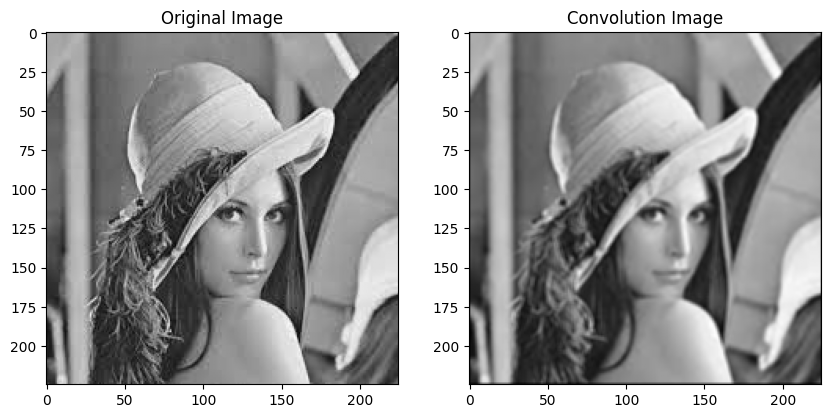

In [7]:
img=cv2.imread('lena.jpeg',0)

def general_convolution(img,kernel):
    img_h,img_w=img.shape
    kernel_h,kernel_w=kernel.shape
    pad_h=kernel_h//2
    pad_w=kernel_w//2
    
    padded_img=np.pad(img,((pad_h,pad_h),(pad_w,pad_w)),mode='constant',constant_values=0)
    
    output_img=np.zeros((img_h,img_w))
    
    for i in range(img_h):
        for j in range(img_w):
            reg=padded_img[i:i+kernel_h,j:j+kernel_w]
            output_img[i,j]=np.sum(reg*kernel)
            
    return output_img
kernel=np.ones((3,3))/9
conv_img = general_convolution(img, kernel)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)   
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.subplot(1,2,2)
plt.imshow(conv_img, cmap='gray')
plt.title('Convolution Image')

b) Roberts Operator

Text(0.5, 1.0, 'roberts image')

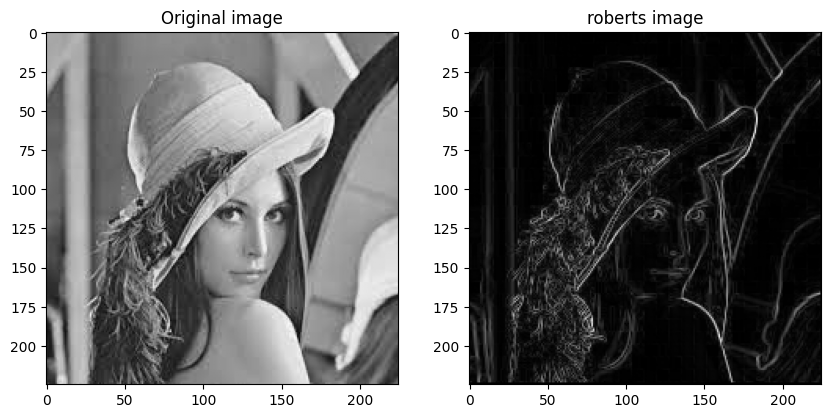

In [8]:
def roberts(img):
    x=np.array([[1,0],[0,-1]])
    y=np.array([[0,1],[-1,0]])
    
    rows,cols=img.shape
    output=np.zeros((rows,cols))
    
    for i in range(rows-1):
        for j in range(cols-1):
            reg=img[i:i+2,j:j+2]
            
            gx=np.sum(reg*x)
            gy=np.sum(reg*y)
            
            output[i,j]=np.sqrt(gx**2+gy**2)
            
    return output
r_img=roberts(img)

r_img=np.clip(r_img,0,255)
r_img=r_img.astype(np.uint8)


plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(r_img,cmap='gray')
plt.title("roberts image")




c) Prewitt operators 

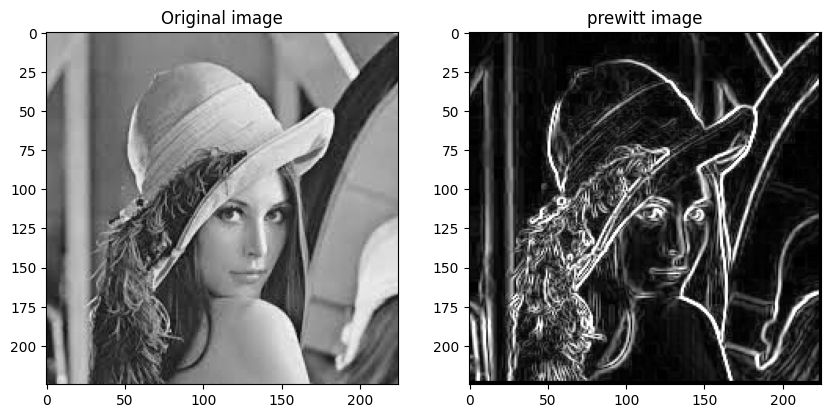

In [ ]:
def prewitt(img):
    x=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
    y=np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
    
    rows,cols=img.shape
    output=np.zeros((rows,cols))
    
    for i in range(rows-2):
        for j in range(cols-2):
            reg=img[i:i+3,j:j+3]
            
            gx=np.sum(reg*x)
            gy=np.sum(reg*y)
            
            output[i,j]=np.sqrt(gx**2+gy**2)
            
    return output
p_img=prewitt(img)
p_img=np.clip(p_img,0,255)
p_img=p_img.astype(np.uint8)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(p_img,cmap='gray')
plt.title("Prewitt image")
plt.show()


d) sobel operator

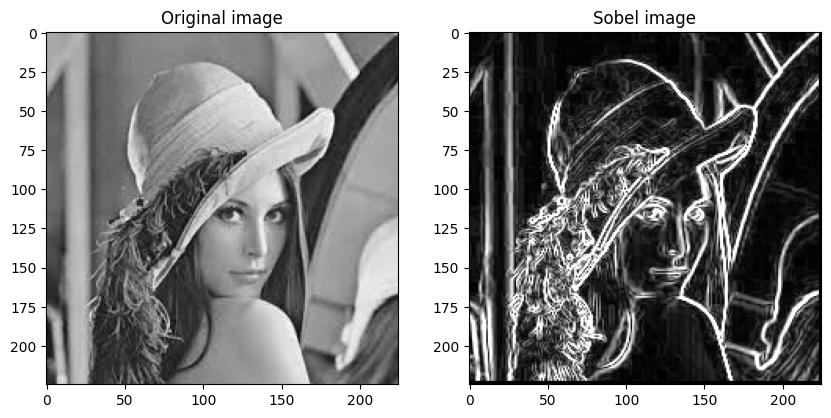

In [10]:
def sobel(img):
    x=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    y=np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
    
    rows,cols=img.shape
    output=np.zeros((rows,cols))
    
    for i in range(rows-2):
        for j in range(cols-2):
            reg=img[i:i+3,j:j+3]
            
            gx=np.sum(reg*x)
            gy=np.sum(reg*y)
            
            output[i,j]=np.sqrt(gx**2+gy**2)
            
    return output
s_img=sobel(img)
s_img=np.clip(s_img,0,255)
s_img=s_img.astype(np.uint8)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(s_img,cmap='gray')
plt.title("Sobel image")
plt.show()

e) Laplacian Operator

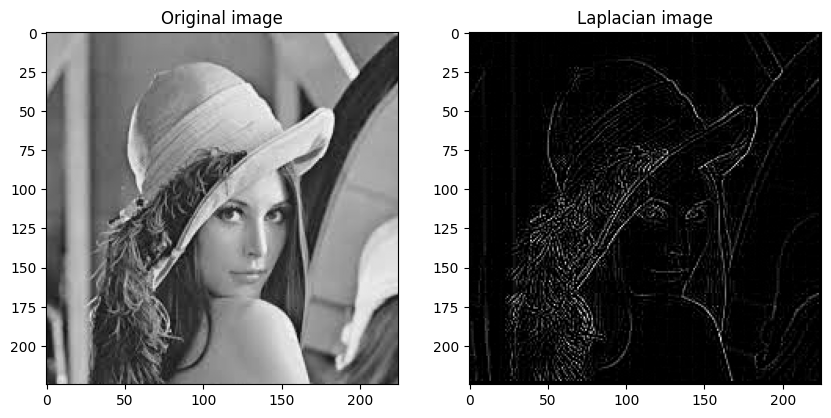

In [11]:
def laplacian(img):
    kernel=np.array([[0,1,0],[1,-4,1],[0,1,0]])
    
    rows,cols=img.shape
    output=np.zeros((rows,cols))
    
    for i in range(rows-2):
        for j in range(cols-2):
            reg=img[i:i+3,j:j+3]
            
            output[i,j]=np.sum(reg*kernel)
            
    return output
l_img=laplacian(img)
l_img=np.clip(l_img,0,255)
l_img=l_img.astype(np.uint8)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(l_img,cmap='gray')
plt.title("Laplacian image")
plt.show()


f) Median Filtering

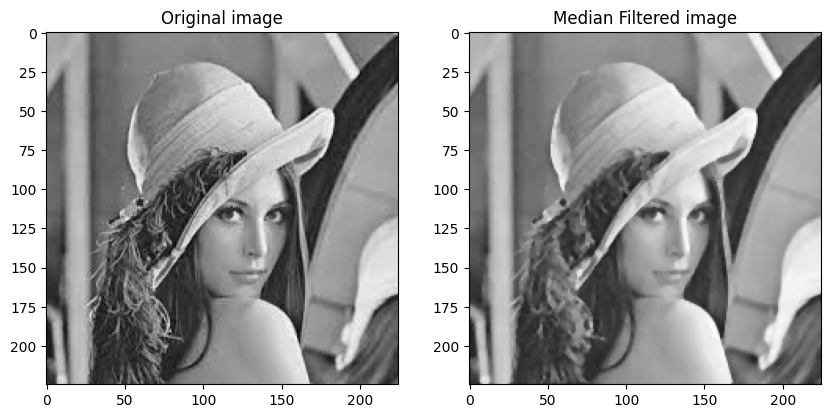

In [12]:
def median_filter(img,kernel_size):
    pad=kernel_size//2
    padded_img=np.pad(img,((pad,pad),(pad,pad)),mode='constant',constant_values=0)
    
    rows,cols=img.shape
    output=np.zeros((rows,cols))
    
    for i in range(rows):
        for j in range(cols):
            reg=padded_img[i:i+kernel_size,j:j+kernel_size]
            output[i,j]=np.median(reg)
            
    return output
m_img=median_filter(img,3)
m_img=np.clip(m_img,0,255)
m_img=m_img.astype(np.uint8)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(m_img,cmap='gray')
plt.title("Median Filtered image")
plt.show()

g) Average filtering

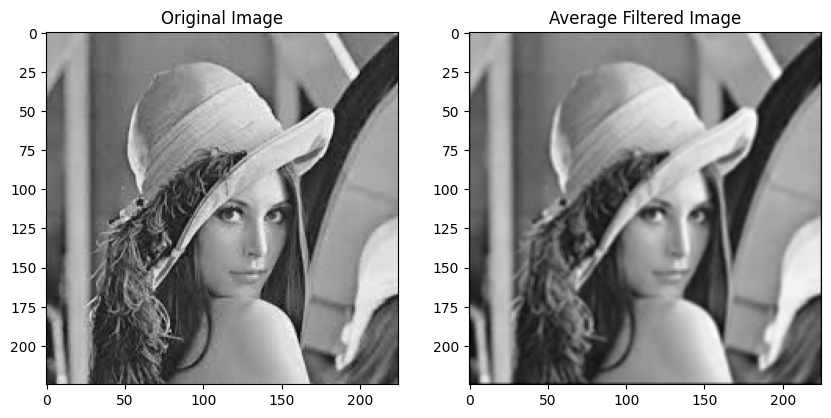

In [13]:
def avg_filter(img,kernel_size):
    kernel=np.ones((kernel_size,kernel_size))/(kernel_size**2)
    
    return general_convolution(img,kernel)
a_img=avg_filter(img,3)
a_img=np.clip(a_img,0,255)
a_img=a_img.astype(np.uint8)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.subplot(1,2,2)
plt.imshow(a_img, cmap='gray')
plt.title('Average Filtered Image')
plt.show()